In [1]:
import numpy as np, pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt

two_phase_T = {
    "CO2": (216.592, 304.128),
    "O2":  (54.361, 154.599),
    "H2S": (187.700, 373.101),
    "N2":  (63.151, 126.192),
    "CO":  (68.160, 132.860),
    "H2":  (13.957, 33.144),
    "Ar":  (83.806, 150.687),
    "CH4": (90.694, 190.564),
}

pairs = list(combinations(two_phase_T.keys(), 2))

print("Number of components:", len(two_phase_T))
print("Number of unique pairs:", len(pairs))

for comp1, comp2 in pairs:
    Ttr1, Tc1 = two_phase_T[comp1]
    Ttr2, Tc2 = two_phase_T[comp2]

    T_low = max(Ttr1, Ttr2)
    T_high = min(Tc1, Tc2)

    if T_low < T_high:
        print(
            f"{comp1}-{comp2}: "
            f"{T_low:.3f} to {T_high:.3f} K "
            f"({T_low - 273.15:.3f} to {T_high - 273.15:.3f} °C)"
        )
    else:
        print(f"{comp1}-{comp2}: no common two-phase temperature range")

Number of components: 8
Number of unique pairs: 28
CO2-O2: no common two-phase temperature range
CO2-H2S: 216.592 to 304.128 K (-56.558 to 30.978 °C)
CO2-N2: no common two-phase temperature range
CO2-CO: no common two-phase temperature range
CO2-H2: no common two-phase temperature range
CO2-Ar: no common two-phase temperature range
CO2-CH4: no common two-phase temperature range
O2-H2S: no common two-phase temperature range
O2-N2: 63.151 to 126.192 K (-209.999 to -146.958 °C)
O2-CO: 68.160 to 132.860 K (-204.990 to -140.290 °C)
O2-H2: no common two-phase temperature range
O2-Ar: 83.806 to 150.687 K (-189.344 to -122.463 °C)
O2-CH4: 90.694 to 154.599 K (-182.456 to -118.551 °C)
H2S-N2: no common two-phase temperature range
H2S-CO: no common two-phase temperature range
H2S-H2: no common two-phase temperature range
H2S-Ar: no common two-phase temperature range
H2S-CH4: 187.700 to 190.564 K (-85.450 to -82.586 °C)
N2-CO: 68.160 to 126.192 K (-204.990 to -146.958 °C)
N2-H2: no common two-pha

In [2]:
# Read data
df = pd.read_csv("../CombinedDatasetSEC_A4.csv")

print(df.columns)

# Clean column names
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

# Mixture CO2 partial density gap
df["NUM1"] = df["rhoL_carbon_dioxide"] - df["rhoV_carbon_dioxide"]
df["DEN1"] = df["rhoL0_carbon_dioxide"] - df["rhoV0_carbon_dioxide"]

# Reference density-gap ratio
df["r1"] = df["NUM1"] / df["DEN1"]
df["r1sq"] = df["r1"] ** 2

# WSD baseline if only CO2 contributes
# gamma_base = gamma0_CO2 * r1^2
df["gamma_base"] = df["gamma0_carbon_dioxide"] * df["r1sq"]

# Corrected cDFT value
df["gamma_cDFT"] = df["gamma_wsd"] + df["gamma_cDFT_minus_wsd_uncorrected"]

# Difference between calculated gamma_base and stored gamma_wsd_UC
df["gamma_base_minus_gamma_wsd_UC"] = df["gamma_base"] - df["gamma_wsd_UC"]
df["abs_difference"] = df["gamma_base_minus_gamma_wsd_UC"].abs()

# Print first 10 rows for checking
print(df[[
    "gamma_wsd",
    "gamma_base",
    "gamma_wsd_UC",
    "gamma_base_minus_gamma_wsd_UC",
    "abs_difference",
    "gamma_cDFT"
]].head(10))

# Find rows where gamma_base and gamma_wsd_UC are not equal
mask = ~np.isclose(
    df["gamma_base"],
    df["gamma_wsd_UC"],
    rtol=1e-10,
    atol=1e-12
)

# Print unique source_id values for outliers
print("Unique source_id values for outliers:")
print(df.loc[mask, "source_id"].dropna().unique() + 1)

# Create outliers dataframe
outliers = df.loc[mask].copy()

# Columns to save in outliers file
outlier_cols = [
    "source_id",
    "gamma_wsd",
    "gamma_base",
    "gamma_wsd_UC",
    "gamma_base_minus_gamma_wsd_UC",
    "abs_difference",
    "gamma_cDFT",
]

# Save outliers to separate CSV file
outliers[outlier_cols].to_csv("outliers.csv", index=False)
print("Number of outliers:", len(outliers))

Index(['T', 'P', 'z_argon', 'z_carbon dioxide', 'z_carbon monoxide',
       'z_hydrogen', 'z_hydrogen sulfide', 'z_methane', 'z_nitrogen',
       'z_oxygen', 'rho_l', 'rho_v', 'x_argon', 'x_carbon dioxide',
       'x_carbon monoxide', 'x_hydrogen', 'x_hydrogen sulfide', 'x_methane',
       'x_nitrogen', 'x_oxygen', 'y_argon', 'y_carbon dioxide',
       'y_carbon monoxide', 'y_hydrogen', 'y_hydrogen sulfide', 'y_methane',
       'y_nitrogen', 'y_oxygen', 'rhoL_argon', 'rhoL_carbon dioxide',
       'rhoL_carbon monoxide', 'rhoL_hydrogen', 'rhoL_hydrogen sulfide',
       'rhoL_methane', 'rhoL_nitrogen', 'rhoL_oxygen', 'rhoV_argon',
       'rhoV_carbon dioxide', 'rhoV_carbon monoxide', 'rhoV_hydrogen',
       'rhoV_hydrogen sulfide', 'rhoV_methane', 'rhoV_nitrogen', 'rhoV_oxygen',
       'Pc_carbon dioxide', 'Psat0_carbon dioxide', 'Tc_carbon dioxide',
       'gamma0_carbon dioxide', 'rhoL0_carbon dioxide', 'rhoV0_carbon dioxide',
       'gamma_wsd', 'gamma_wsd_UC', 'gamma_cDFT_minus_wsd_c

In [3]:
df          = pd.read_csv("../CombinedDatasetSEC_A4.csv")
df.columns  = [col.strip().replace(" ", "_") for col in df.columns]

# Keep only rows needed to calculate gamma_cDFT and residual
df = df.dropna(subset=["gamma_wsd","gamma_cDFT_minus_wsd_uncorrected","gamma_wsd_UC"]).copy()

# Recalculate gamma_cDFT
df["gamma_cDFT_UC"] = df["gamma_wsd_UC"] + df["gamma_cDFT_minus_wsd_uncorrected"]
df["gamma_cDFT"]    = df["gamma_wsd"] + df["gamma_cDFT_minus_wsd_corrected"]

# Check equality with tolerance
tol = 1e-10

mask = ~np.isclose(
    df["gamma_cDFT_UC"],
    df["gamma_cDFT"],
    rtol=tol,
    atol=tol
)

if mask.any():
    print("WARNING: gamma_cDFT_UC and gamma_cDFT are not equal for some rows.")
    print("Number of mismatched rows:", mask.sum())

    for idx, row in df.loc[mask].iterrows():
        print(
            f"Row {idx}: "
            f"source_id={row.get('source_id', 'NA')}, "
            f"gamma_cDFT_UC={row['gamma_cDFT_UC']}, "
            f"gamma_cDFT={row['gamma_cDFT']}, "
            f"difference={row['gamma_cDFT_UC'] - row['gamma_cDFT']}"
        )
else:
    print("All rows match within tolerance.")

All rows match within tolerance.


Index(['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen',
       'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide',
       'z_hydrogen sulfide', 'Tc', 'Pc', 'Tr', 'Pr', 'P_bubble', 'P_dew',
       'liquid_density', 'vapor_density', 'x_carbon dioxide', 'x_hydrogen',
       'x_nitrogen', 'x_argon', 'x_methane', 'x_oxygen', 'x_carbon monoxide',
       'x_hydrogen sulfide', 'y_carbon dioxide', 'y_hydrogen', 'y_nitrogen',
       'y_argon', 'y_methane', 'y_oxygen', 'y_carbon monoxide',
       'y_hydrogen sulfide', 'gamma', 'interfacial_thickness',
       'E_carbon dioxide', 'E_hydrogen', 'E_nitrogen', 'E_argon', 'E_methane',
       'E_oxygen', 'E_carbon monoxide', 'E_hydrogen sulfide', 'gamma0_CO2',
       'rhoL0_CO2', 'rhoV0_CO2', 'Tc_CO2', 'Psat_CO2', 'source_id'],
      dtype='object')
    temperature    P_bubble      P_dew
0         200.0  162.875312   2.768427
1         205.0  145.203986   3.541001
2         210.0  130.851954   4.470789
3         215.0  119

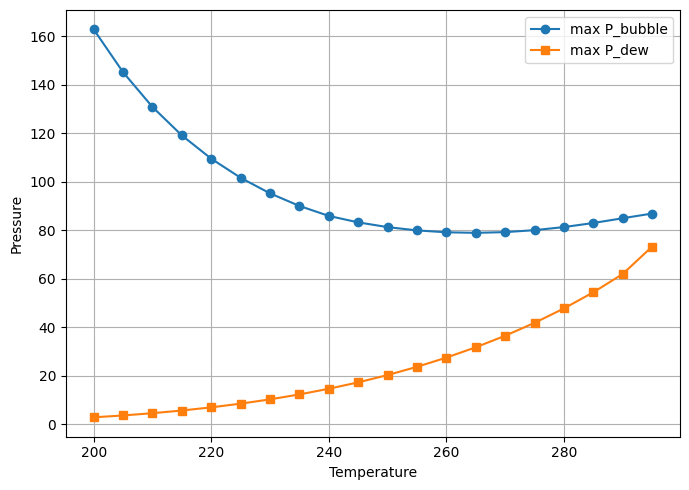

In [7]:

# Read data
df = pd.read_csv("../../interfacial_results_dataset_A4.csv")

print(df.columns)

# Take maximum P_bubble and P_dew at each temperature
df_max = (
    df.groupby("temperature", as_index=False)[["P_bubble", "P_dew"]]
      .max()
      .sort_values("temperature")
)

print(df_max)

# Plot maximum P_bubble and maximum P_dew vs temperature
plt.figure(figsize=(7, 5))

plt.plot(df_max["temperature"].iloc[:-1], df_max["P_bubble"].iloc[:-1], "o-", label="max P_bubble")
plt.plot(df_max["temperature"].iloc[:-1], df_max["P_dew"].iloc[:-1], "s-", label="max P_dew")

plt.xlabel("Temperature")
plt.ylabel("Pressure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
df[['temperature', 'P_bubble', 'P_dew']]

,temperature,P_bubble,P_dew
0,200.0,11.721694,2.708496
1,200.0,11.721694,2.708496
2,200.0,11.721694,2.708496
3,200.0,11.721694,2.708496
4,200.0,11.721694,2.708496
...,...,...,...
19356,295.0,77.713923,66.469193
19357,295.0,77.713923,66.469193
19358,295.0,77.713923,66.469193
19359,295.0,77.713923,66.469193
